In [1]:
import os
from src.files.files import get_files

files = get_files()
original_files = files.get_original_files()
filtered_files = files.get_filtered_files()

with original_files.get_genome_file().open_or_recompute() as fullFasta:
    with filtered_files.get_genome_file().open_or_recompute() as filteredFasta:
        fullFasta.seek(0, os.SEEK_END)
        filteredFasta.seek(0, os.SEEK_END)
        
        print("Fasta filtered from size:", fullFasta.tell(), "to size", filteredFasta.tell())

with original_files.get_annotations_file().open_or_recompute() as fullGtf:
    with filtered_files.get_annotations_file().open_or_recompute() as filteredGtf:
        fullLines = sum(1 for _ in fullGtf)
        filteredLines = sum(1 for _ in filteredGtf)

        print("Annotations filtered from", fullLines, "lines to", filteredLines, "lines")

with original_files.get_modifications_file().open_or_recompute() as fullBed:
    with filtered_files.get_modifications_file().open_or_recompute() as filteredBed:
        fullLines = sum(1 for _ in fullBed)
        filteredLines = sum(1 for _ in filteredBed)

        print("Modifications filtered from", fullLines, "lines to", filteredLines, "lines")

Fasta filtered from size: 3339739109 to size 146952938
Annotations filtered from 4727823 lines to 165373 lines
Modifications filtered from 882385 lines to 28408 lines


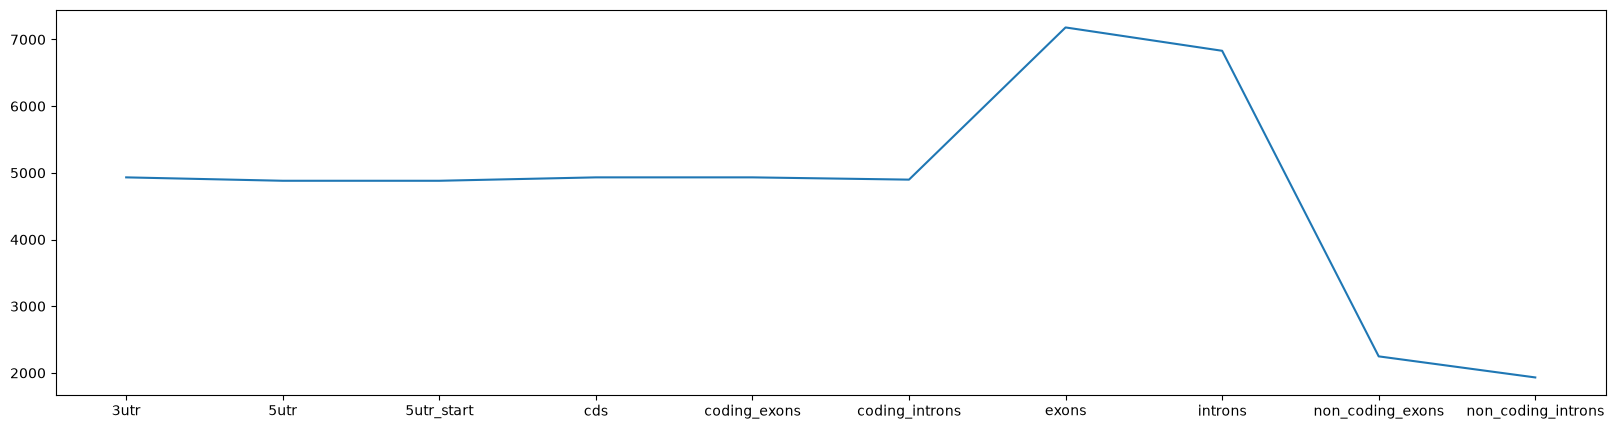

In [2]:
import matplotlib.pyplot as plt
from src.files.files import get_files

line_counts = {}

for key, file in get_files().get_assembled_region_files().get_files_dict().items():
    line_counts[key] = sum(1 for _ in file.open_or_recompute())

fig, axs = plt.subplots(figsize=(20, 5))
axs.plot(line_counts.keys(), line_counts.values())
plt.show()

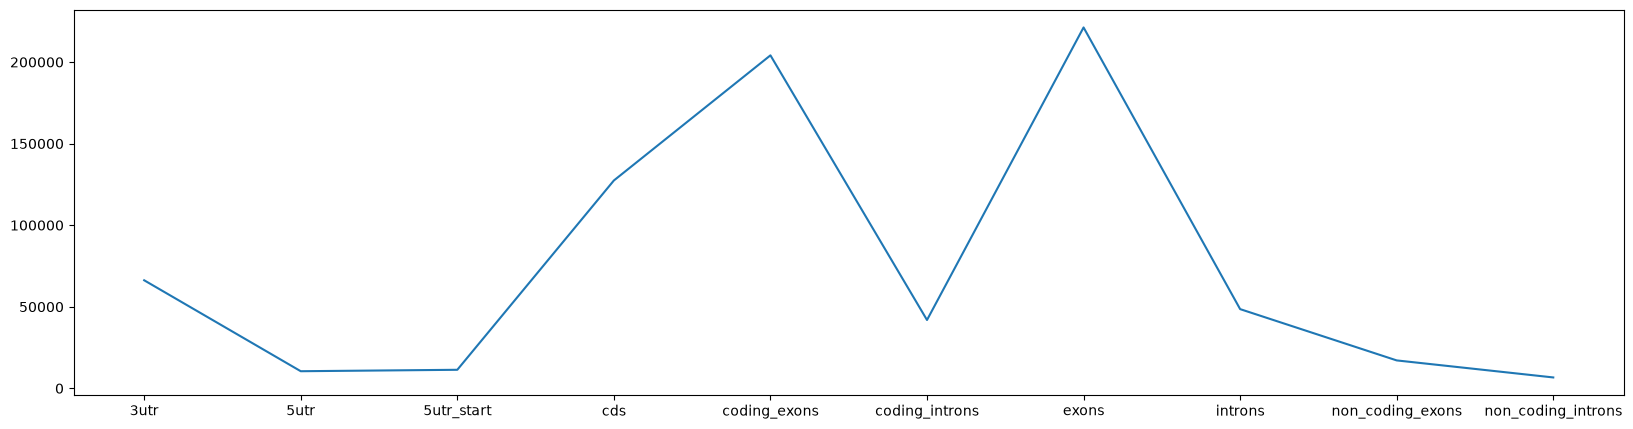

In [4]:
import matplotlib.pyplot as plt
from src.files.files import get_files

line_counts = {}

for key, file in get_files().get_assembled_region_intersects_files().get_files_dict().items():
    line_counts[key] = sum(1 for _ in file.open_or_recompute())

fig, axs = plt.subplots(figsize=(20, 5))
axs.plot(line_counts.keys(), line_counts.values())
plt.show()

/tmp/ipykernel_142207/592847462.py:87: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


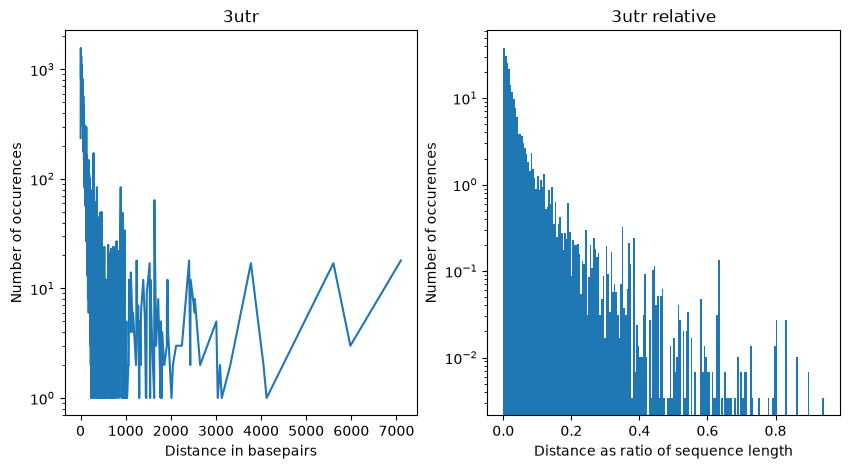

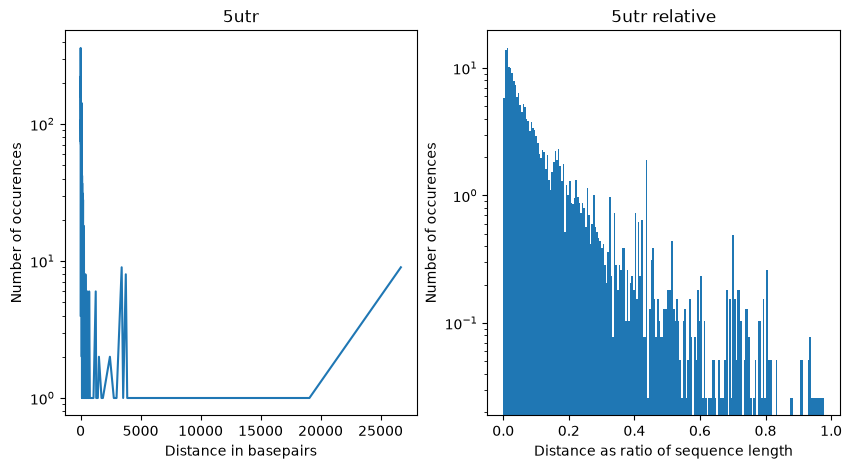

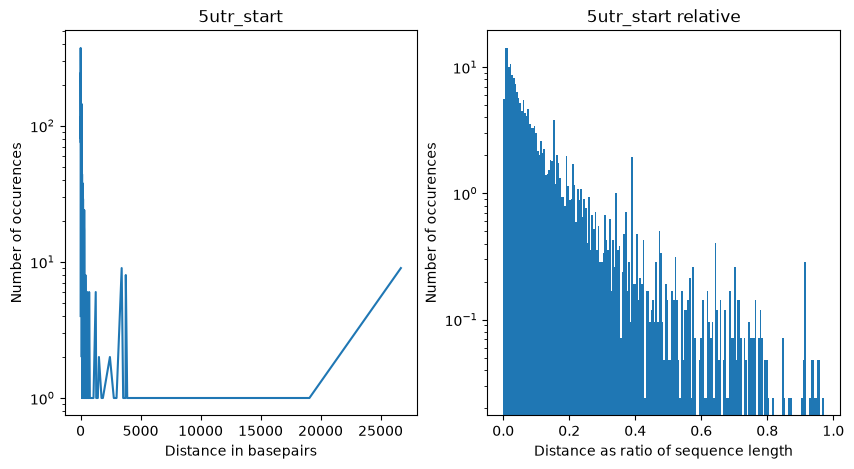

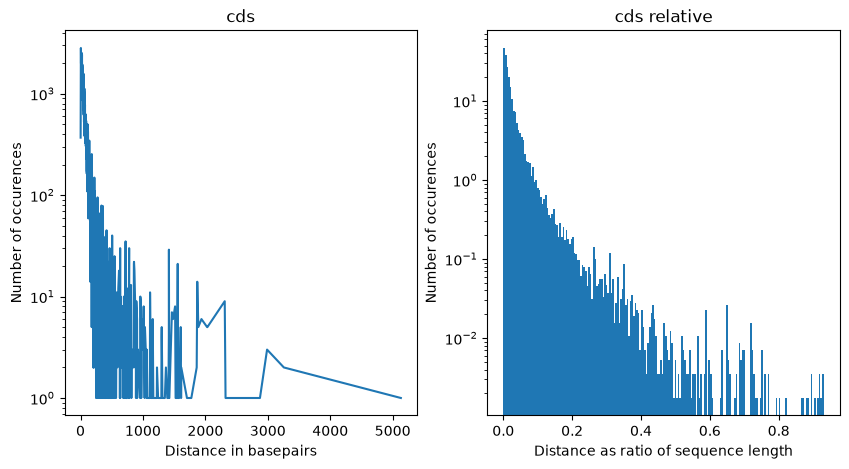

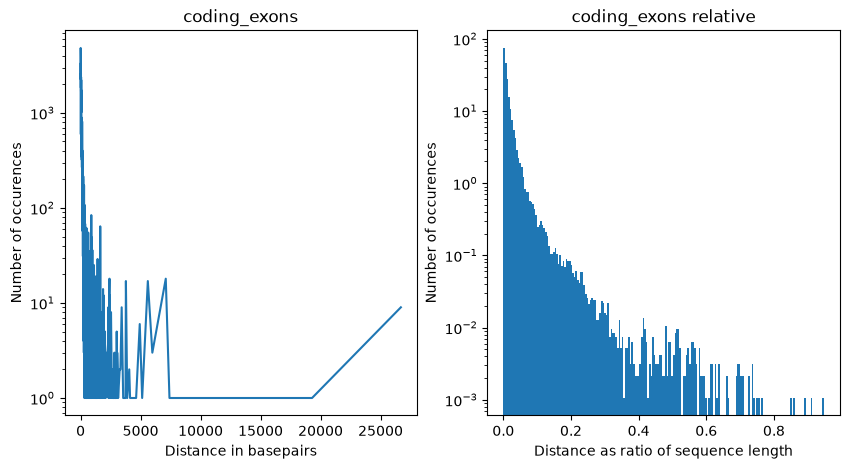

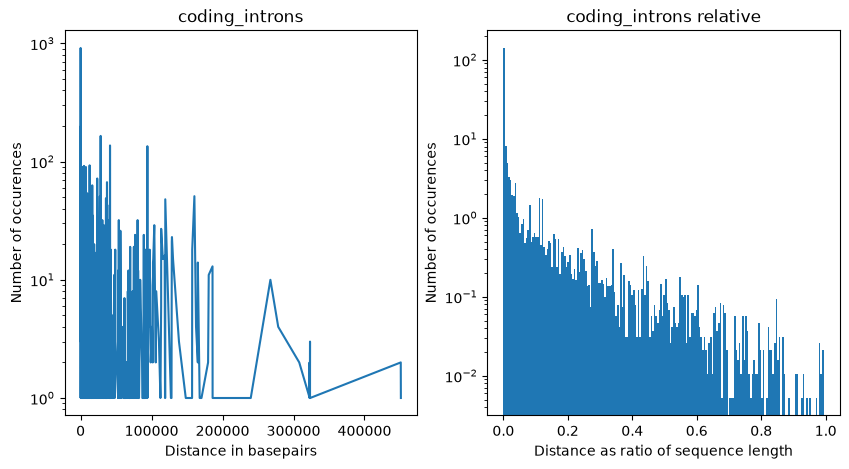

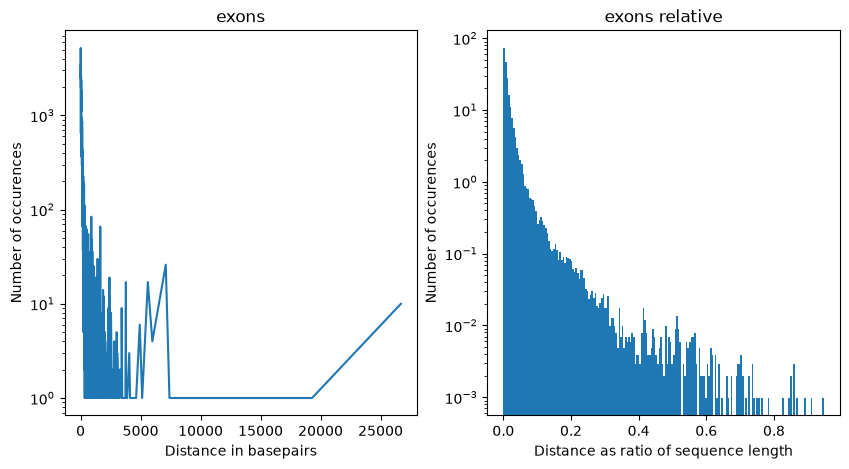

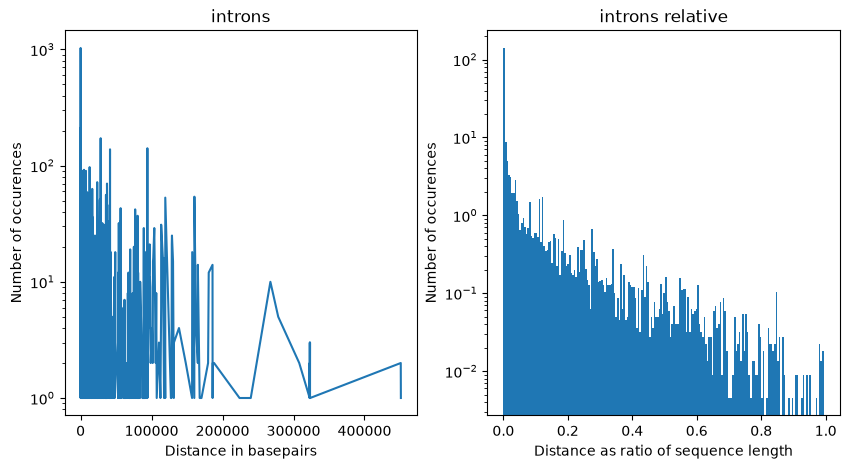

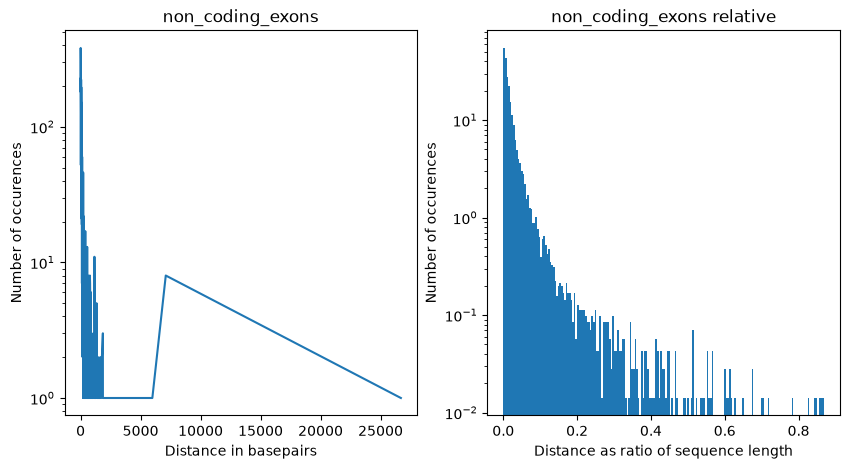

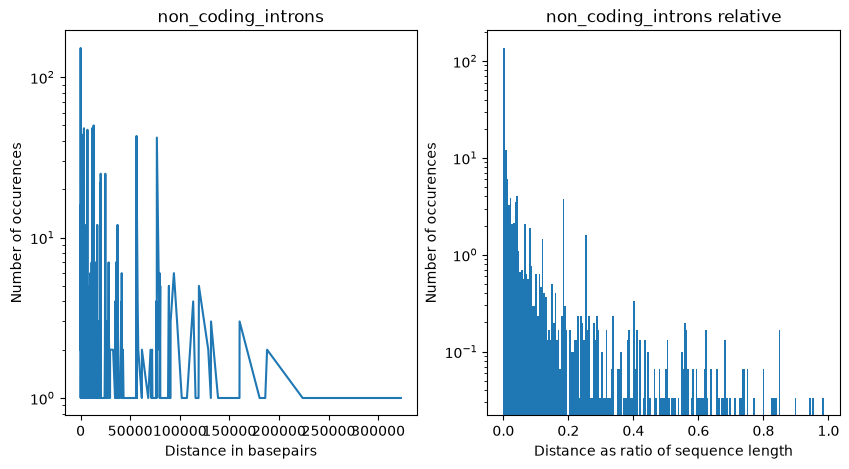

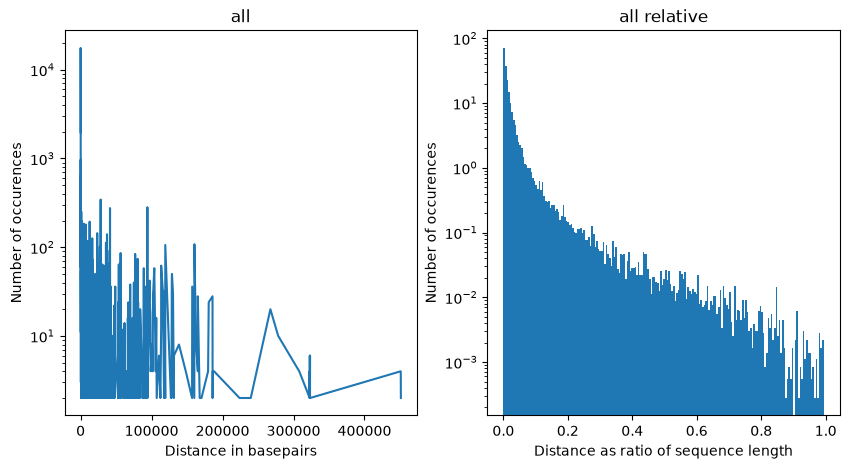

In [42]:
from src.util import load_region_modifications
from src.files.files import get_files
import matplotlib.pyplot as plt
from collections import defaultdict
from fasta import FASTA
import sys

distances = defaultdict(lambda: defaultdict(int))
relative_distances = defaultdict(list)

def compute_modification_distances(region):
    local_distances = defaultdict(int)
    
    modifications = region.modifications

    if len(modifications) < 2:
        return local_distances

    for i in range(len(modifications) - 1):
        first = modifications[i]
        second = modifications[i + 1]

        distance = second - first

        local_distances[distance] = local_distances[distance] + 1

    return local_distances

for key, file in get_files().get_assembled_region_local_intersects_assembled_files().get_files_dict().items():
    get_files().get_assembled_region_fasta_files().get_files_dict()[key].open_or_recompute()

    fastaFile = FASTA(get_files().get_assembled_region_fasta_files().get_files_dict()[key].get_possibly_gzip_path())

    regions = load_region_modifications(file)

    for entry in fastaFile:
        region_name = entry.name[:entry.name.find(":")]
        
        if (not region_name in regions) or len(regions[region_name].modifications) == 0:
            continue

        region_size = len(str(entry.seq))

        region = regions[region_name]
        
        region_distances = compute_modification_distances(region)

        for distance, count in region_distances.items():
            distances[key][distance] += count

            relative_distance = distance / region_size
            
            for _ in range(count):
                relative_distances[key].append(relative_distance)  

all_key_distances = defaultdict(int)
all_key_relative_distances = []

for key in distances.keys():
    for distance in distances[key]:
        all_key_distances[distance] += distances[key][distance]
    all_key_relative_distances += relative_distances[key]

distances["all"] = all_key_distances
relative_distances["all"] = all_key_relative_distances

num_bins = 200

for key in distances.keys():
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].set_title(key)
    axs[0].set_xlabel("Distance in basepairs")
    axs[0].set_ylabel("Number of occurences")
    axs[0].set_yscale("log")
    data_tuples = sorted(distances[key].items(), key=lambda data: data[0])
    data_x = [x[0] for x in data_tuples]
    data_y = [x[1] for x in data_tuples]
    axs[0].plot(data_x, data_y)

    axs[1].set_title(key + " relative")
    axs[1].set_xlabel("Distance as ratio of sequence length")
    axs[1].set_ylabel("Number of occurences")
    axs[1].set_yscale("log")
    axs[1].hist(relative_distances[key], num_bins, density=1)

    fig.subplots_adjust(hspace=1.0)
    fig.show()

/tmp/ipykernel_142207/860883427.py:52: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


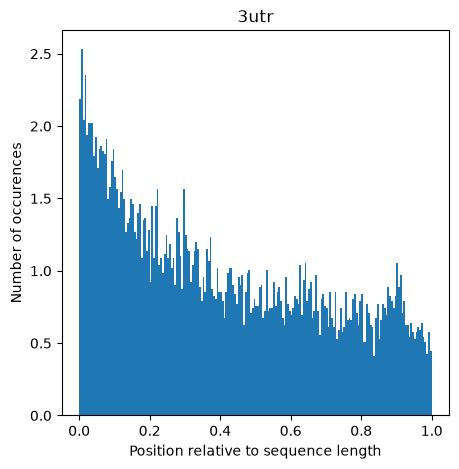

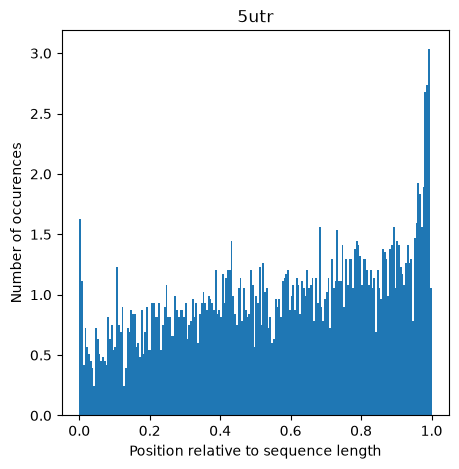

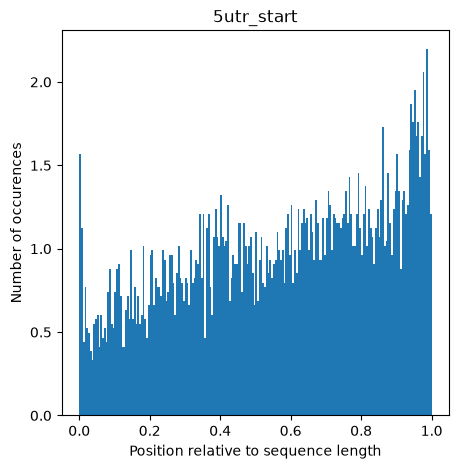

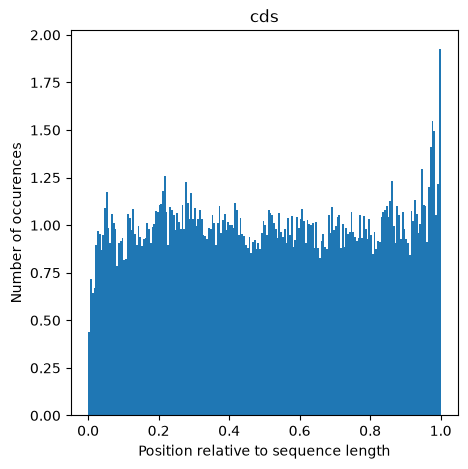

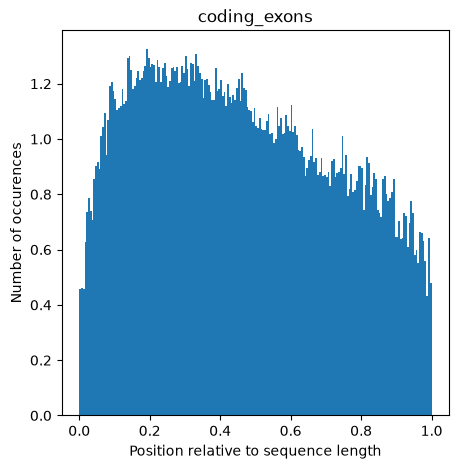

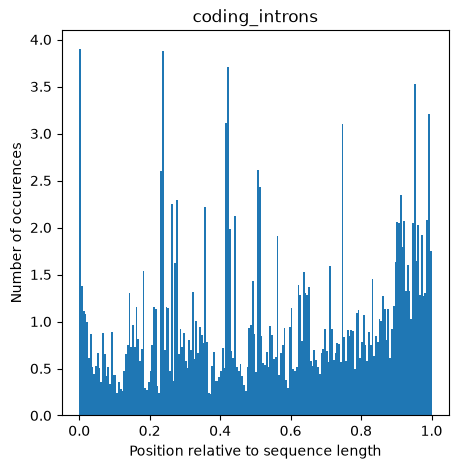

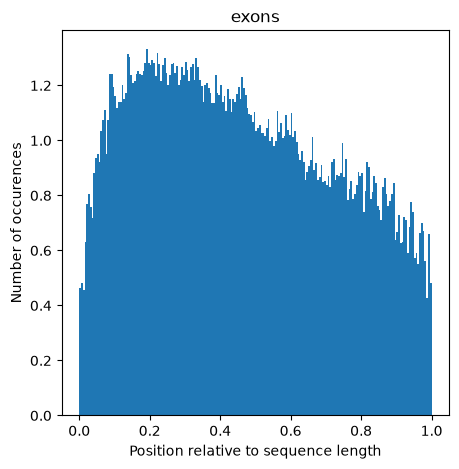

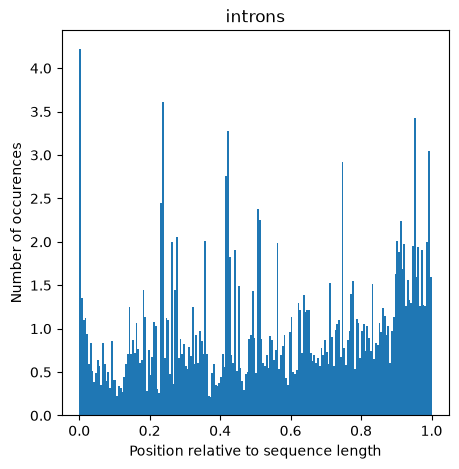

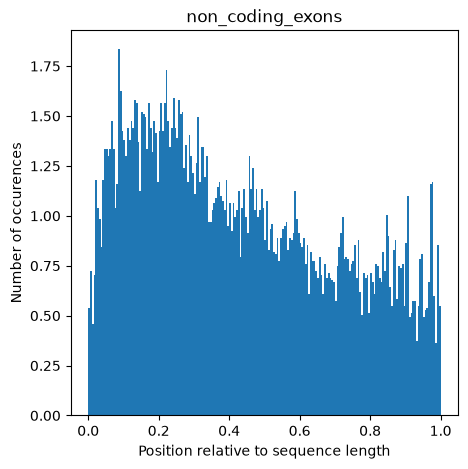

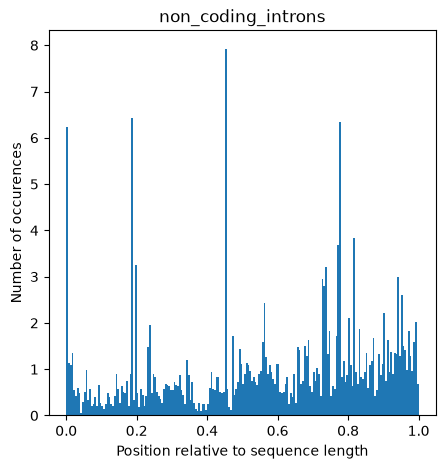

In [38]:
from fasta import FASTA
from src.util import load_region_modifications
from src.files.files import get_files
import numpy as np

num_bins = 200

relative_positions = {}

for key, file in get_files().get_assembled_region_fasta_files().get_files_dict().items():
    relative_positions[key] = []

    read_sequences = {}
    
    regions = load_region_modifications(get_files().get_assembled_region_local_intersects_assembled_files().get_files_dict()[key])
    
    file.open_or_recompute()
    fasta_file = FASTA(file.get_possibly_gzip_path())

    for entry in fasta_file:
        region_name = entry.name[:entry.name.find(":")]

        if not region_name in regions or len(regions[region_name].modifications) == 0:
            continue
        
        sequence = str(entry.seq)

        sequence_length = len(sequence)

        modifications = regions[region_name].modifications

        modifications.sort()

        modifications_str = ",".join(map(str, modifications))

        if (sequence, modifications_str) in read_sequences:
            continue

        read_sequences[(sequence, modifications_str)] = True
        
        for modification in modifications:
            relative_positions[key].append(modification / sequence_length)

for key, data in relative_positions.items():
    fig, axs = plt.subplots(figsize=(5, 5))
    
    axs.hist(data, num_bins, density=1)
    axs.set_title(key)
    axs.set_xlabel("Position relative to sequence length")
    axs.set_ylabel("Number of occurences")
    
    fig.show()


# Accessibility

NM_178857.6_exon
8014
[1688, 1707, 1770, 2658, 5402, 5412, 5429]
1538
5579


/home/erik/bio-prak/mypython/plot.py:43: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


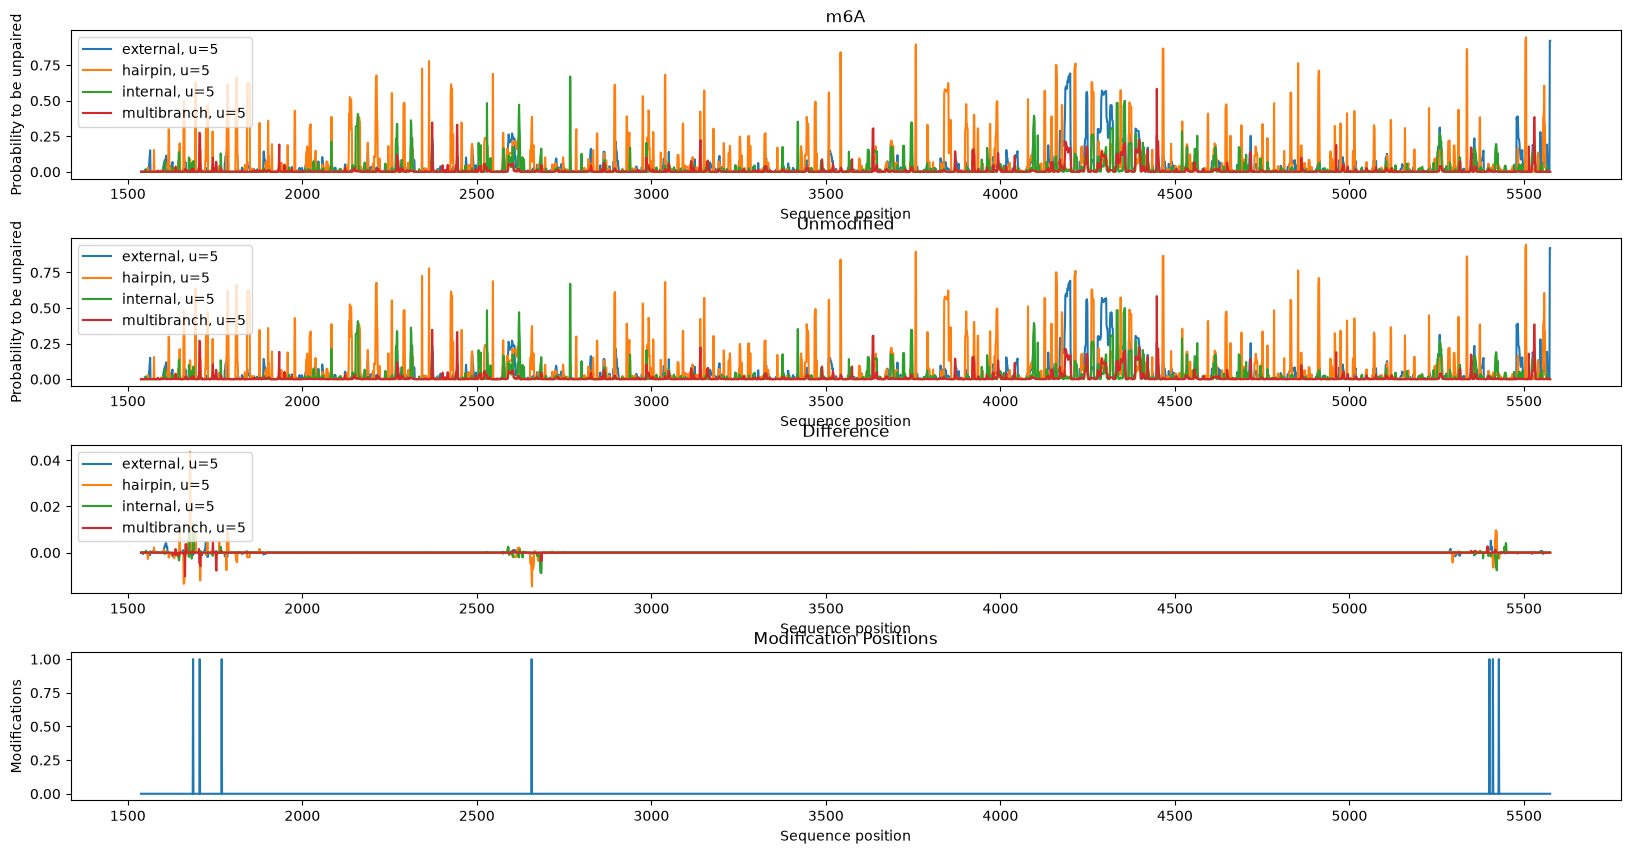

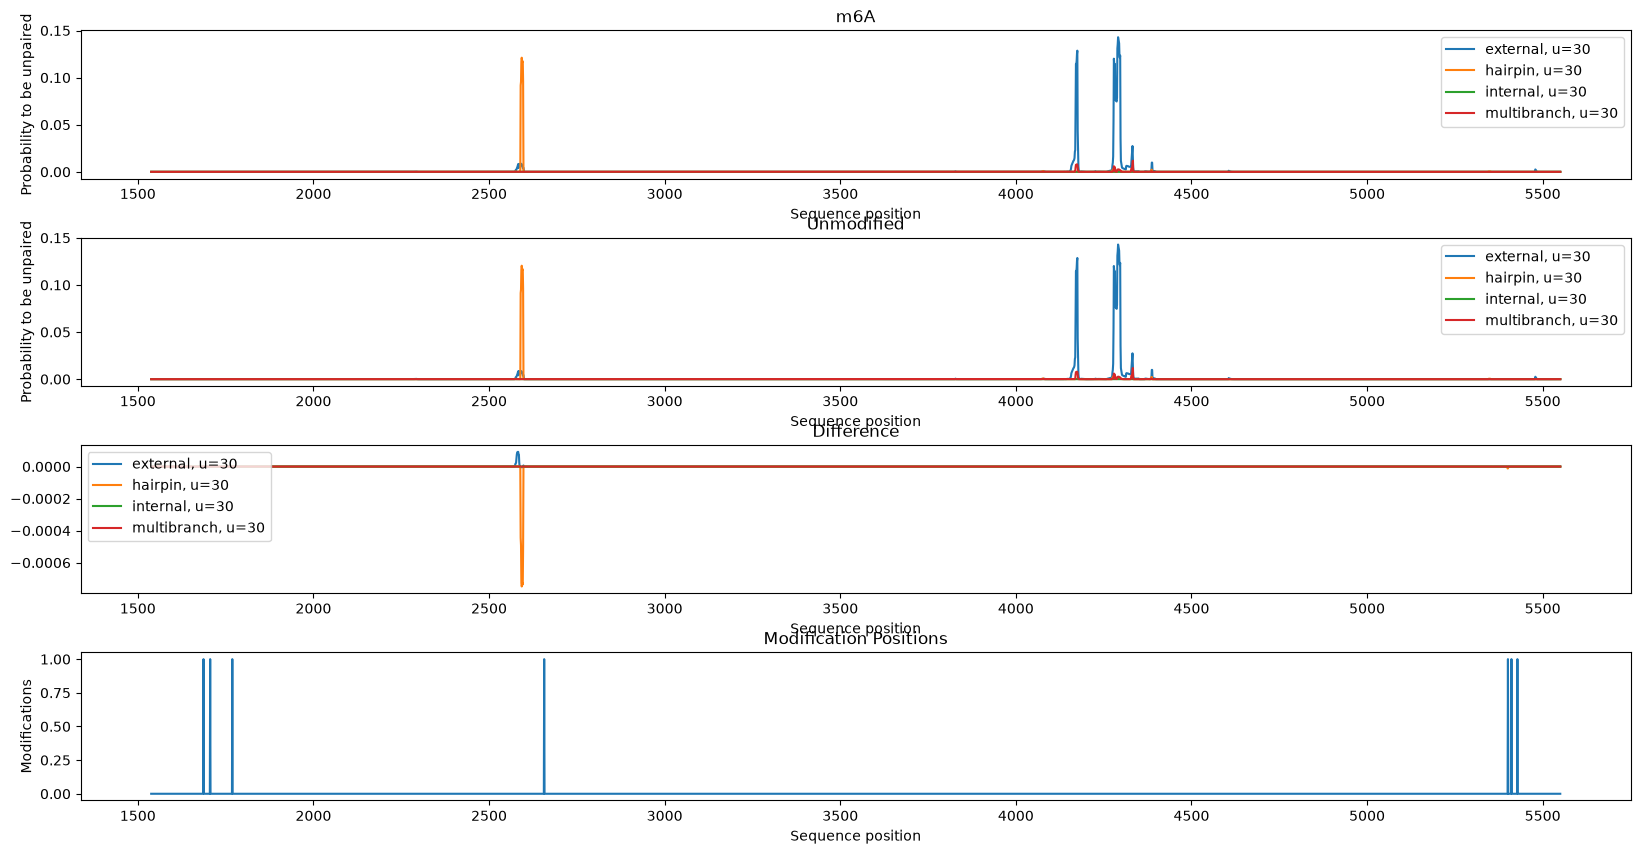

In [5]:
from mypython.algorithms import accessibility, looptypes
from mypython.plot import plot_accessibilities
from fasta import FASTA
from src.util import load_region_modifications
from src.files.files import get_files
import matplotlib.pyplot as plt

fastaFile = get_files().get_assembled_region_fasta_files().get_exons_file()
fastaFile.open_or_recompute()

file = FASTA(fastaFile.get_possibly_gzip_path())
regions = load_region_modifications(get_files().get_assembled_region_local_intersects_assembled_files().get_exons_file())

footprints = [5, 30]
windowsize = 150
L = 100

def map_entry(entry):
    region_name = entry.name[:entry.name.find(":")]
    sequence = str(entry.seq).upper().replace("T", "U")

    modifications = []
    
    if region_name in regions:
        modifications = regions[region_name].modifications

    return (region_name, sequence, modifications)

def filter_entry(entry):
    return len(entry[2]) != 0

def filter_length(entry):
    length = len(entry[1])
    return length > 8000 and length < 9000

modified_regions = filter(filter_length, filter(filter_entry, map(map_entry, file)))

for region_name, sequence, modifications in modified_regions:
    print(region_name)
    print(len(sequence))

    modifications = [x + 1 for x in modifications]
    print(modifications)

    start = max(0, modifications[0] - windowsize)
    end = min(len(sequence), modifications[len(modifications) - 1] + windowsize)

    sequence = sequence[start:end]
    modifications = [x - start for x in modifications]
    print(start)
    print(end)
    data_unmod = accessibility(sequence, footprints, windowsize = windowsize, L = L)
    data = accessibility(sequence, footprints, windowsize = windowsize, L = L, m6A_sites = modifications)

    plot_accessibilities(sequence, footprints, looptypes, start, end, data, data_unmod, modifications)
    break